<h1 style="color:darkblue";>EXPOLATORY DATA ANALYSIS</h1>

In [1]:
import pandas as pd
import seaborn as  sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import RandomOverSampler

In [2]:
poland_df = pd.read_csv("data/poland_df.csv")
poland_df.head()

,Attr1,Attr2,Attr3,Attr4,Attr5,Attr6,Attr7,Attr8,Attr9,Attr10,...,Attr57,Attr58,Attr59,Attr60,Attr61,Attr62,Attr63,Attr64,bankrupt_class,bankrupt_after_years
0,0.200550,0.37951,0.39641,2.0472,32.3510,0.38825,0.249760,1.33050,1.1389,0.50494,...,0.39718,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.4277,0,0
1,0.209120,0.49988,0.47225,1.9447,14.7860,0.00000,0.258340,0.99601,1.6996,0.49788,...,0.42002,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.9870,0,0
2,0.248660,0.69592,0.26713,1.5548,-1.1523,0.00000,0.309060,0.43695,1.3090,0.30408,...,0.81774,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.2078,0,0
3,0.081483,0.30734,0.45879,2.4928,51.9520,0.14988,0.092704,1.86610,1.0571,0.57353,...,0.14207,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.5497,0,0
4,0.187320,0.61323,0.22960,1.4063,-7.3128,0.18732,0.187320,0.63070,1.1559,0.38677,...,0.48431,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.8980,0,0


<h2 style="color:darkblue";> Getting more information about the dataset</h2>
<p>This includes feature/column names, NaN Values, datatypes</p>

In [3]:
poland_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43405 entries, 0 to 43404
Data columns (total 66 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Attr1                 43397 non-null  float64
 1   Attr2                 43397 non-null  float64
 2   Attr3                 43397 non-null  float64
 3   Attr4                 43271 non-null  float64
 4   Attr5                 43316 non-null  float64
 5   Attr6                 43397 non-null  float64
 6   Attr7                 43397 non-null  float64
 7   Attr8                 43311 non-null  float64
 8   Attr9                 43396 non-null  float64
 9   Attr10                43397 non-null  float64
 10  Attr11                43361 non-null  float64
 11  Attr12                43271 non-null  float64
 12  Attr13                43278 non-null  float64
 13  Attr14                43397 non-null  float64
 14  Attr15                43369 non-null  float64
 15  Attr16             

In [4]:
poland_df.describe()

,Attr1,Attr2,Attr3,Attr4,Attr5,Attr6,Attr7,Attr8,Attr9,Attr10,...,Attr57,Attr58,Attr59,Attr60,Attr61,Attr62,Attr63,Attr64,bankrupt_class,bankrupt_after_years
count,43397.000000,43397.000000,43397.000000,43271.000000,4.331600e+04,43397.000000,43397.000000,43311.000000,43396.000000,43397.000000,...,43398.000000,4.332100e+04,43398.000000,4.125300e+04,43303.000000,4.327800e+04,43271.000000,42593.000000,43405.000000,43405.000000
mean,0.035160,0.590212,0.114431,6.314702,-3.853466e+02,-0.056107,0.093478,12.640779,2.652166,0.626868,...,-0.010510,3.002644e+01,1.333288,4.480858e+02,17.033202,1.502328e+03,9.343074,72.788592,0.048174,0.135468
std,2.994109,5.842748,5.439429,295.434425,6.124303e+04,7.201326,5.713075,505.894281,62.932732,14.670597,...,13.674072,5.334454e+03,122.104445,3.234560e+04,553.049406,1.392667e+05,124.177354,2369.339482,0.214137,0.666887
min,-463.890000,-430.870000,-479.960000,-0.403110,-1.190300e+07,-508.410000,-517.480000,-141.410000,-3.496000,-479.910000,...,-1667.300000,-1.986900e+02,-327.970000,-1.244000e+01,-12.656000,-2.336500e+06,-1.543200,-10677.000000,0.000000,0.000000
25%,0.003429,0.268980,0.021521,1.049500,-4.908000e+01,0.000000,0.005776,0.430275,1.018500,0.295470,...,0.014649,8.753200e-01,0.000000,5.545500e+00,4.510150,4.214400e+01,3.097650,2.176800,0.000000,0.000000
50%,0.049660,0.471900,0.196610,1.569800,-1.034500e+00,0.000000,0.059634,1.070400,1.195350,0.505970,...,0.119670,9.509600e-01,0.006366,9.791700e+00,6.636300,7.132600e+01,5.087600,4.282500,0.000000,0.000000
75%,0.129580,0.688320,0.403390,2.787450,5.063425e+01,0.089446,0.150880,2.615700,2.062500,0.709100,...,0.284605,9.926400e-01,0.236052,2.018100e+01,10.394500,1.172200e+02,8.598850,9.776200,0.000000,0.000000
max,94.280000,480.960000,28.336000,53433.000000,1.250100e+06,543.250000,649.230000,53432.000000,9742.300000,1099.500000,...,552.640000,1.108300e+06,23853.000000,4.818700e+06,108000.000000,2.501600e+07,23454.000000,294770.000000,1.000000,5.000000


<h1 style="color:darkblue";>The Target</h1>

<p>The bankrupt_class(Binary Classification) and the bankrupt_after_years columns(Multi-Classification)</p>

In [5]:
poland_df["bankrupt_class"].head()

0    0
1    0
2    0
3    0
4    0
Name: bankrupt_class, dtype: int64

In [6]:
poland_df["bankrupt_after_years"].head()

0    0
1    0
2    0
3    0
4    0
Name: bankrupt_after_years, dtype: int64

<h1 style="color:darkblue";>Class Distribution </h1>

In [7]:
poland_df["bankrupt_class"].value_counts(normalize=True)

bankrupt_class
0    0.951826
1    0.048174
Name: proportion, dtype: float64

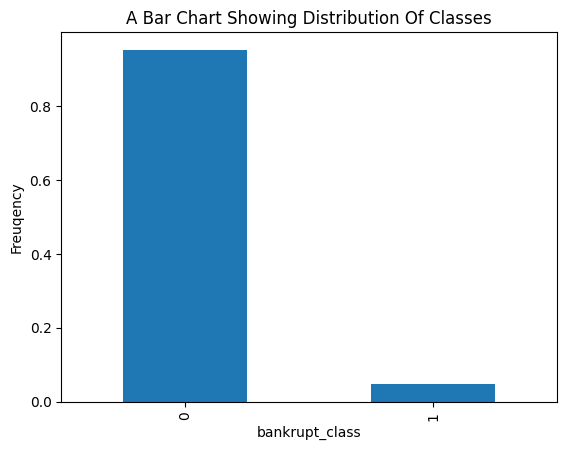

In [8]:
# A Plot showing Distribution of classes
poland_df["bankrupt_class"].value_counts(normalize=True).plot(kind="bar")
plt.title("A Bar Chart Showing Distribution Of Classes")
plt.ylabel("Freuqency");

***From the above we can conclude that with the given data more companies have no threat of running bankrupt_class whereas there are a few with chances of running bankrupt_class***

In [9]:
poland_df["bankrupt_after_years"].value_counts(normalize=True)

bankrupt_after_years
0    0.951826
2    0.011865
3    0.011404
1    0.009446
4    0.009216
5    0.006244
Name: proportion, dtype: float64

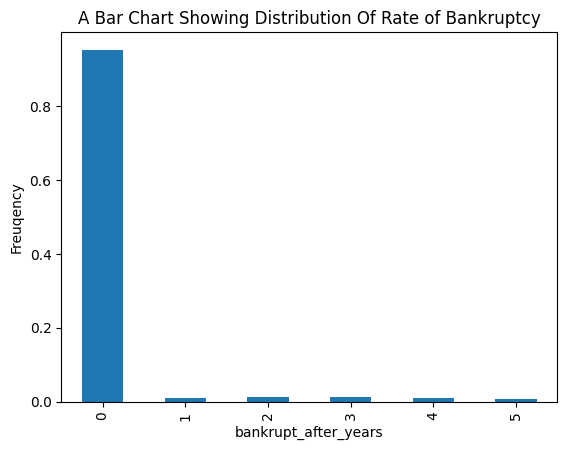

In [10]:
# A Plot showing Distribution of classes
poland_df["bankrupt_after_years"].value_counts(normalize=True).sort_index().plot(kind="bar")
plt.title("A Bar Chart Showing Distribution Of Rate of Bankruptcy")
plt.ylabel("Freuqency");

<h2 style="color:darkblue";> Detecting Outliers using Attr27 </h2>

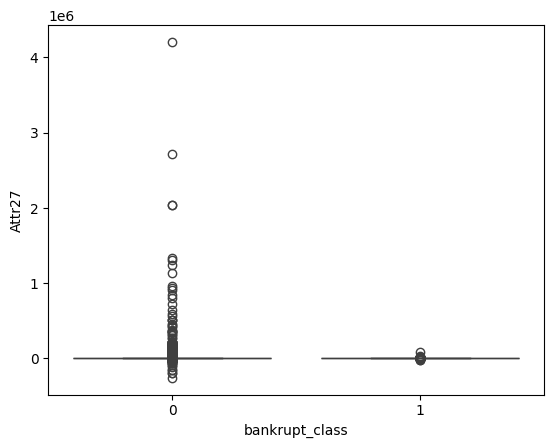

In [11]:
sns.boxplot(x="bankrupt_class", y="Attr27", data=poland_df);

In [12]:
# Clipping data (Removing Outliers when the data is skewed)
q1,q2 = poland_df["Attr27"].quantile([0.1,0.9])
poland_df["Attr27"] = poland_df["Attr27"].clip(q1,q2)

<h2 style="color:darkblue";>  The correlation heat map</h2>

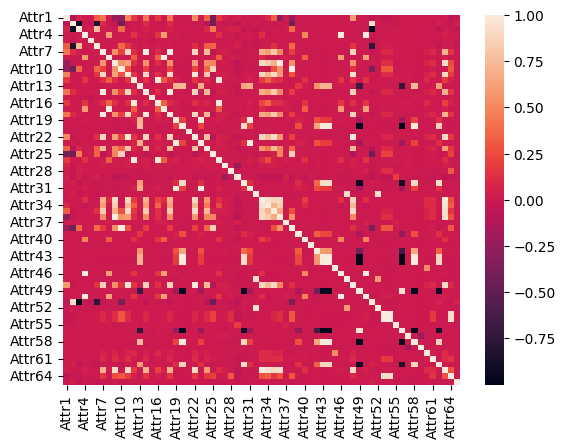

In [13]:
corr = poland_df.drop(columns="bankrupt_class").corr()
sns.heatmap(corr);